In [2]:
from few.utils.Extra_for_project.flux_calculations import nex_ELdot,few_ELdot
from few.utils.geodesic import get_separatrix, get_fundamental_frequencies
import numpy as np
import matplotlib.pyplot as plt
from few.utils.mappings.kerrecceq import DELTAPMAX_REGIONC,DELTAPMIN_REGIONC
from few.utils.mappings.jacobian import ELdot_to_PEdot_Jacobian
import pandas as pd
from scipy.interpolate import LinearNDInterpolator

def _EdotPN_alt(p, e):
    """
    https://arxiv.org/pdf/2201.07044.pdf
    eq 91
    """
    oneme2 = (1 - e**2) ** 1.5
    Edot = 32.0 / 5.0 * p ** (-5) * oneme2 * (1 + 73 / 24 * e**2 + 37 / 96 * e**4)
    return Edot

KerrEccEqFluxData_nex.h5
All good
KerrEccEqFluxData_nex.h5
KerrEccEqFluxData_nex.h5
All good


In [3]:
data_in = np.loadtxt('Ollies_flux_data.txt')
columns = ["a", "p", "Edot_tot"]
df = pd.DataFrame(data_in, columns=columns)

In [5]:

with pd.option_context('display.max_rows', None,
    'display.max_columns', 12,
    'display.width', 13000,
    'display.precision', 10):
        print(df)


                a          p      Edot_tot
0    0.9700000000   1.614100  0.0810252013
1    0.9700000000   1.650000  0.0765814741
2    0.9700000000   1.700000  0.0708507838
3    0.9700000000   1.750000  0.0655821844
4    0.9700000000   1.800000  0.0607228037
5    0.9700000000   1.900000  0.0520866750
6    0.9700000000   2.000000  0.0447116259
7    0.9700000000   2.100000  0.0384181171
8    0.9700000000   2.200000  0.0330591004
9    0.9700000000   2.500000  0.0213055153
10   0.9700000000   2.700000  0.0160824179
11   0.9700000000   3.000000  0.0107456412
12   0.9700000000   3.500000  0.0057728102
13   0.9700000000   4.000000  0.0032891084
14   0.9980000000   1.236970  0.0903245808
15   0.9980000000   1.300000  0.0909807298
16   0.9980000000   1.400000  0.0870406102
17   0.9980000000   1.500000  0.0798737603
18   0.9980000000   1.600000  0.0715488651
19   0.9980000000   1.700000  0.0631678415
20   0.9980000000   1.800000  0.0552765065
21   0.9980000000   1.900000  0.0481117068
22   0.9980

In [14]:
get_separatrix(0.998,0,1)- 1.236970

6.551751763339553e-07

In [3]:
Edot_PN = _EdotPN_alt(df["p"],0)

Ollie_Edot_interp_norm = LinearNDInterpolator(list(zip(df["a"], df["p"])), -df["Edot_tot"] / Edot_PN)

def Ollie_Edot_interp(a,p):
    return Ollie_Edot_interp_norm(a,p)*_EdotPN_alt(p,0)

### Check exact values in flux file

In [13]:
def Ollie_flux(a,p):
    match = df[(df.iloc[:, 0] == a) & (df.iloc[:, 1] == p)]
    if not match.empty:
        return match.iloc[0, 2]  # value from the third column
    raise ValueError("no ,a,p value")

a_vals = df["a"]
p_vals = df["p"]
Edot_ollie_arr= df["Edot_tot"]

In [14]:
Edot_zach = []
Edot_few = []
Edot_ollie = []
for a,p,edot_ollie in zip(a_vals,p_vals,Edot_ollie_arr):
    edot_zach = nex_ELdot(a,p,0,1)[0]
    edot_few = few_ELdot(a,p,0,1)[0]


    if p < get_separatrix(a,0,1)+DELTAPMIN_REGIONC:
        continue

    Edot_few.append(edot_few)
    Edot_zach.append(edot_zach)
    Edot_ollie.append(-edot_ollie)

    rel_diff = np.abs((edot_zach - -edot_ollie)/(edot_zach))

        
Edot_few=np.asarray(Edot_few)
Edot_zach=np.asarray(Edot_zach)
Edot_ollie=np.asarray(Edot_ollie)
    

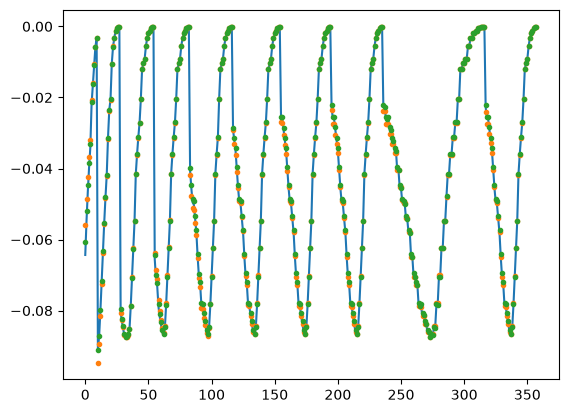

In [15]:
plt.plot(Edot_few)
plt.plot(Edot_zach,".")
plt.plot(Edot_ollie,".")



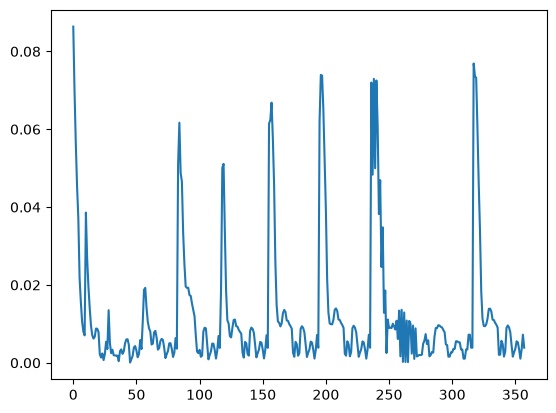

In [16]:
rel_diff = np.abs((Edot_zach - Edot_ollie)/(Edot_zach))
plt.plot(rel_diff)

In [59]:
a,p,e,x = 0.998,10 ,0 ,1
nex_ELdot(a,p,e,x)[0], few_ELdot(a,p,e,x)[0] , Ollie_flux(a,p)

(-4.9600551932262e-05,
 -4.942512180625564e-05,
 np.float64(4.942512177217305e-05))

### Check interpolated error

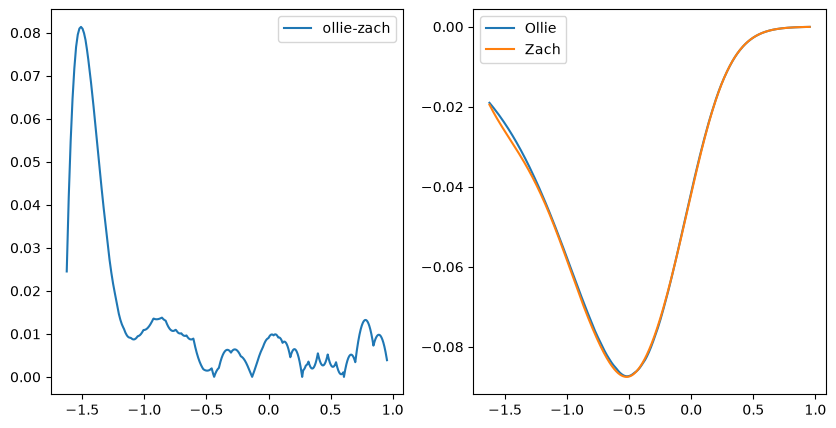

In [98]:
n = 9
a,e,x=1-10**(-n),0,1
psep = get_separatrix(a,e,x)
p= np.linspace(psep+DELTAPMIN_REGIONC,psep+9,10000)
a = np.ones_like(p)*a
e = np.ones_like(p)*e
x = np.ones_like(p)*x

ollie = Ollie_Edot_interp(a,p)
zach = nex_ELdot(a,p,e,x)[0]
few = few_ELdot(a,p,e,x)[0]

rel_diff_OZ = np.abs((ollie-zach)/ollie)
#rel_diff_OF = np.abs((ollie-few)/ollie)
#rel_diff_ZF = np.abs((zach-few)/zach)

fig, axs = plt.subplots(1,2,figsize = (10,5))

x1 = np.log10(p-psep)
x2 = p

axs[0].plot(x1,rel_diff_OZ,label = "ollie-zach")
#plt.plot(p,rel_diff_OF,label = "ollie-few")
#plt.plot(p,rel_diff_ZF,label = "zach-few")

axs[1].plot(x1, ollie,label  = "Ollie")
axs[1].plot(x1, zach,label  = "Zach")

axs[0].legend()
axs[1].legend()

#plt.plot(p,ollie)
#plt.plot(p,zach)

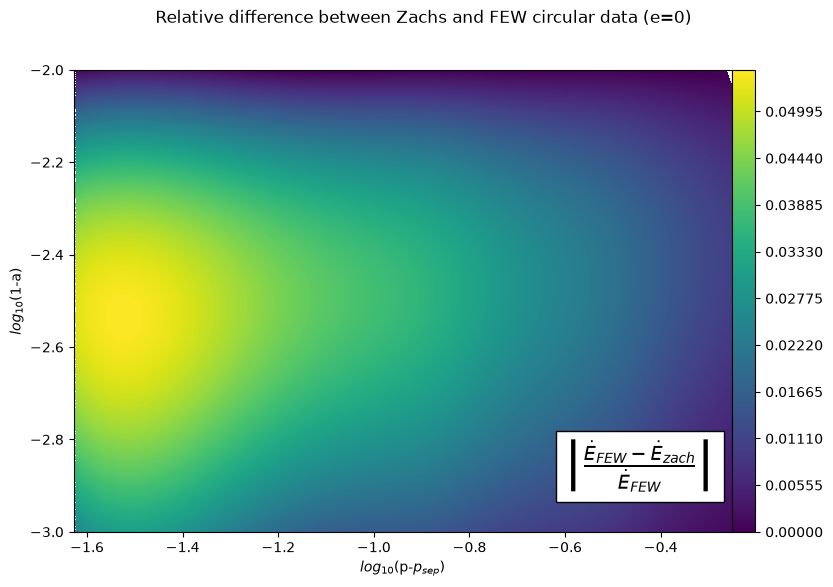

In [24]:
x=1
n1,n2 =2000,2000
e=0.0

a = 1 - np.logspace(-2, -3, n1)
#a=np.geomspace(0.999,1-10**(-12),n1)
p= np.linspace(1,2,n2)

A, P = np.meshgrid(a, p)
E= np.zeros_like(P)
X= np.ones_like(P)
PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

deltap =   DELTAPMIN_REGIONC

#Add near-extremal data
Z_nex = nex_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())

Z_nex = Z_nex[0].reshape(n1,n2)
Z_nex_masked = np.where(P > PSEP+np.ones_like(PSEP)*deltap, Z_nex, np.nan)


#Add FEW data
Z_few = few_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())

Z_few = Z_few[0].reshape(n1,n2)
Z_few_masked = np.where(P > PSEP+np.ones_like(PSEP)*deltap, Z_few, np.nan)

'''
#Add ollies data
Z_ollie = Ollie_Edot_interp(A.flatten(),P.flatten())  
Z_ollie = Z_ollie.reshape(n1,n2)

Z_ollie_masked = np.where(P > PSEP+np.ones_like(PSEP)*deltap, Z_ollie, np.nan)
'''

rel_diff = np.abs((Z_few_masked - Z_nex_masked)/Z_few_masked)

fig, ax = plt.subplots(1,1,figsize = (10,6))
lvls =500

x1 = np.log10(np.abs(P-PSEP))
x2 = P-PSEP
cf1 = ax.contourf(x1, np.log10(1-A), rel_diff, levels=lvls, cmap="viridis")
cb = fig.colorbar(cf1, ax=ax,pad = 0)
cb.set_label(r"$\left|\frac{\dot{E}_{FEW}-\dot{E}_{zach}}{\dot{E}_{FEW}}\right|$", rotation =0 ,
             labelpad=-250,fontsize=20,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )

cb.ax.yaxis.set_label_coords(-4, 0.2)
ax.set_xlim(-1.628,-0.25)

ax.set_xlabel(r"$log_{10}$(p-$p_{sep}$)")
ax.set_ylabel(r"$log_{10}$(1-a)")

plt.suptitle("Relative difference between Zachs and FEW circular data (e=0)          ")
plt.show()
#fig.savefig(f"contourplot_a_vs_p_e=0_rel_diff_zach_FEW.png", dpi=300, bbox_inches="tight")

In [6]:
DELTAPMIN_REGIONC

0.023713737056616554

In [7]:
10**(-1.625)

0.023713737056616554

In [51]:
nex_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())[0]

array([-0.04177836, -0.04177809, -0.04177781, ..., -0.01040115,
       -0.0103999 , -0.01039782], shape=(1000000,))

In [73]:
np.isnan(Z_ollie_masked).any()    ,  np.isnan(Z_nex_masked).any() 

(np.True_, np.False_)

In [77]:
1-np.logspace(-3,-10,30)

array([0.999     , 0.99942638, 0.99967097, 0.99981126, 0.99989174,
       0.9999379 , 0.99996438, 0.99997957, 0.99998828, 0.99999328,
       0.99999614, 0.99999779, 0.99999873, 0.99999927, 0.99999958,
       0.99999976, 0.99999986, 0.99999992, 0.99999995, 0.99999997,
       0.99999999, 0.99999999, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

## Convert ollies to pdot and edot

In [19]:
Edot = np.asarray(df["Edot_tot"])
agrid = np.asarray(df["a"])
pgrid = np.asarray(df["p"])
egrid = np.zeros_like(agrid)
xgrid = np.sign(agrid)
xgrid[xgrid == 0] = 1

freq , _,_ = get_fundamental_frequencies(agrid,pgrid,egrid,xgrid)

In [20]:

Edothere = Edot.flatten()
Ldothere = Edothere*freq

out_pdot_edot = np.asarray(
    [
        ELdot_to_PEdot_Jacobian(
            agrid[i],
            pgrid[i],
            egrid[i],
            xgrid[i],
            Edothere[i],
            Ldothere[i],
        )
        for i in range(Edothere.size)
    ]
)

ZeroDivisionError: division by zero

In [21]:
for i in range(len(Edothere)):
    print(i,
    agrid[i],
    pgrid[i],
    egrid[i],
    xgrid[i],
    Edothere[i],
    Ldothere[i],
          ELdot_to_PEdot_Jacobian(
            agrid[i],
            pgrid[i],
            egrid[i],
            xgrid[i],
            Edothere[i],
            Ldothere[i],
        ))

0 0.97 1.6141 0.0 1.0 0.08102520126403089 0.026823591019121365 (-3.316387549998277, 0.0)
1 0.97 1.65 0.0 1.0 0.07658147412636471 0.02478795338186289 (-5.093724562680999, 0.0)
2 0.97 1.7 0.0 1.0 0.0708507838311821 0.022234471389714093 (-13.178944365213667, 0.0)
3 0.97 1.75 0.0 1.0 0.0655821843663715 0.01996393838387698 (43.27695149307052, 0.0)
4 0.97 1.8 0.0 1.0 0.0607228037283554 0.01793903675209136 (9.330821947165482, 0.0)
5 0.97 1.9 0.0 1.0 0.052086675025417285 0.014512990000747763 (4.055950046686894, 0.0)


ZeroDivisionError: division by zero

In [11]:
a,p,e,x = 0.999999,1.3,0,1

frq,_,_ = get_fundamental_frequencies(a,p,e,x)

nex_ELdot(a,p,e,x)[0], nex_ELdot(a,p,e,x)[1]*frq

(-0.08747760772634317, -0.08738953761669044)